In [3]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import time
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE, ADASYN, SVMSMOTE
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers

print("=" * 50)
print("Setup")
print("=" * 50)

# Load raw embeddings
print("Loading embeddings...")
debian_emb = np.load("../dataset/debian_embeddings.npy").astype(np.float32)
debian_lbl = np.load("../dataset/debian_labels.npy").astype(np.float32)
chrome_emb = np.load("../dataset/chrome_embeddings.npy").astype(np.float32)
chrome_lbl = np.load("../dataset/chrome_labels.npy").astype(np.float32)
print(f"  Debian: {debian_emb.shape} | Chrome: {chrome_emb.shape}")

# Normalise
print("Normalising...")
scaler = StandardScaler()
debian_emb_scaled = scaler.fit_transform(debian_emb)
chrome_emb_scaled = scaler.transform(chrome_emb)
print("  Done.")

# Load existing AUC results if available
if os.path.exists("dataset/adversarial_results.json"):
    with open("dataset/adversarial_results.json", "r") as f:
        results = json.load(f)
    print(f"  Loaded existing AUC results: {list(results.keys())}")
else:
    results = {}
    print("  No existing AUC results found. Starting fresh.")

# Shared adversarial validation function
def adversarial_validation(source_emb, target_emb, label="Condition", n_splits=5):
    X = np.vstack([source_emb, target_emb])
    y = np.array([0] * len(source_emb) + [1] * len(target_emb))
    clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    cv  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    auc_scores = []
    fold_bar = tqdm(cv.split(X, y), total=n_splits,
                    desc=f"  [{label}] CV folds", leave=True,
                    bar_format="{l_bar}{bar:25}{r_bar}")
    for train_idx, val_idx in fold_bar:
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        clf.fit(X_train, y_train)
        proba     = clf.predict_proba(X_val)[:, 1]
        fold_auc  = roc_auc_score(y_val, proba)
        auc_scores.append(fold_auc)
        fold_bar.set_postfix({"fold_AUC": f"{fold_auc:.4f}"})
    mean_auc = float(np.mean(auc_scores))
    std_auc  = float(np.std(auc_scores))
    print(f"  → AUC: {mean_auc:.4f} ± {std_auc:.4f}\n")
    return mean_auc, std_auc

def save_results():
    with open("adversarial_results.json", "w") as f:
        json.dump(results, f, indent=2)
    print("  Results saved to adversarial_results.json")

print("\n Setup complete.\n")

Setup
Loading embeddings...
  Debian: (18298, 768) | Chrome: (4436, 768)
Normalising...
  Done.
  No existing AUC results found. Starting fresh.

 Setup complete.



In [4]:
print("=" * 45)
print("No Oversampling")
print("=" * 45)

if "No Oversampling" in results:
    print("  Already computed — skipping.")
    print(f"  AUC: {results['No Oversampling'][0]:.4f} ± {results['No Oversampling'][1]:.4f}")
else:
    auc, std = adversarial_validation(
        debian_emb_scaled, chrome_emb_scaled, label="No Oversampling"
    )
    results["No Oversampling"] = [auc, std]
    save_results()

No Oversampling


  [No Oversampling] CV folds: 100%|█████████████████████████| 5/5 [25:28<00:00, 305.74s/

  → AUC: 0.8508 ± 0.0087

  Results saved to adversarial_results.json


In [7]:
print("=" * 45)
print("SMOTE")
print("=" * 45)

# Load or compute SMOTE embeddings
if os.path.exists("../dataset/debian_smote.npy"):
    print("  Loading SMOTE embeddings from disk...", end=" ", flush=True)
    debian_smote = np.load("dataset/debian_smote.npy")
    print(f"Done. Shape: {debian_smote.shape}")
else:
    print("  Fitting SMOTE...", end=" ", flush=True)
    t0 = time.time()
    smote = SMOTE(random_state=42)
    debian_smote, _smote_lbl = smote.fit_resample(debian_emb_scaled, debian_lbl)
    np.save("../dataset/debian_smote.npy", debian_smote)
    print(f"Done in {time.time()-t0:.1f}s | Shape: {debian_smote.shape}")

# Run adversarial validation
if "SMOTE" in results:
    print("  Already computed — skipping.")
    print(f"  AUC: {results['SMOTE'][0]:.4f} ± {results['SMOTE'][1]:.4f}")
else:
    auc, std = adversarial_validation(
        debian_smote, chrome_emb_scaled, label="SMOTE"
    )
    results["SMOTE"] = [auc, std]
    save_results()

SMOTE
  Fitting SMOTE... Done in 0.1s | Shape: (33766, 768)


  [SMOTE] CV folds: 100%|█████████████████████████| 5/5 [44:32<00:00, 534.52s/it, fold_A

  → AUC: 0.8893 ± 0.0017

  Results saved to adversarial_results.json


In [8]:
print("=" * 45)
print(" ADASYN")
print("=" * 45)

# Load or compute ADASYN embeddings
if os.path.exists("dataset/debian_adasyn.npy"):
    print("  Loading ADASYN embeddings from disk...", end=" ", flush=True)
    debian_adasyn = np.load("../dataset/debian_adasyn.npy")
    print(f"Done. Shape: {debian_adasyn.shape}")
else:
    print("  Fitting ADASYN...", end=" ", flush=True)
    t0 = time.time()
    adasyn = ADASYN(random_state=42)
    debian_adasyn, _adasyn_lbl = adasyn.fit_resample(debian_emb_scaled, debian_lbl)
    np.save("../dataset/debian_adasyn.npy", debian_adasyn)
    print(f"Done in {time.time()-t0:.1f}s | Shape: {debian_adasyn.shape}")

# Run adversarial validation
if "ADASYN" in results:
    print("  Already computed — skipping.")
    print(f"  AUC: {results['ADASYN'][0]:.4f} ± {results['ADASYN'][1]:.4f}")
else:
    auc, std = adversarial_validation(
        debian_adasyn, chrome_emb_scaled, label="ADASYN"
    )
    results["ADASYN"] = [auc, std]
    save_results()

 ADASYN
  Fitting ADASYN... Done in 0.2s | Shape: (33961, 768)


  [ADASYN] CV folds: 100%|█████████████████████████| 5/5 [44:15<00:00, 531.17s/it, fold_

  → AUC: 0.8884 ± 0.0043

  Results saved to adversarial_results.json


In [9]:
print("=" * 45)
print("SVM-SMOTE")
print("=" * 45)

# Load or compute SVM-SMOTE embeddings
if os.path.exists("dataset/debian_svmsmote.npy"):
    print("  Loading SVM-SMOTE embeddings from disk...", end=" ", flush=True)
    debian_svmsmote = np.load("../dataset/debian_svmsmote.npy")
    print(f"Done. Shape: {debian_svmsmote.shape}")
else:
    print("  Fitting SVM-SMOTE (slowest — please wait)...", end=" ", flush=True)
    t0 = time.time()
    svmsmote = SVMSMOTE(random_state=42)
    debian_svmsmote, _svm_lbl = svmsmote.fit_resample(debian_emb_scaled, debian_lbl)
    np.save("../dataset/debian_svmsmote.npy", debian_svmsmote)
    print(f"Done in {time.time()-t0:.1f}s | Shape: {debian_svmsmote.shape}")

# Run adversarial validation
if "SVM-SMOTE" in results:
    print("  Already computed — skipping.")
    print(f"  AUC: {results['SVM-SMOTE'][0]:.4f} ± {results['SVM-SMOTE'][1]:.4f}")
else:
    auc, std = adversarial_validation(
        debian_svmsmote, chrome_emb_scaled, label="SVM-SMOTE"
    )
    results["SVM-SMOTE"] = [auc, std]
    save_results()

SVM-SMOTE
  Fitting SVM-SMOTE (slowest — please wait)... Done in 33.8s | Shape: (33766, 768)


  [SVM-SMOTE] CV folds: 100%|█████████████████████████| 5/5 [41:38<00:00, 499.63s/it, fo

  → AUC: 0.8994 ± 0.0025

  Results saved to adversarial_results.json


In [10]:
print("=" * 45)
print("  BLOCK 5: GAN")
print("=" * 45)

# Load or compute GAN embeddings
if os.path.exists("../dataset/debian_gan_embeddings.npy"):
    print("  Loading GAN embeddings from disk...", end=" ", flush=True)
    debian_gan = np.load("../dataset/debian_gan_embeddings.npy")
    print(f"Done. Shape: {debian_gan.shape}")
else:
    print("  Training GAN from scratch...")
    t0 = time.time()

    latent_dim = 100
    n_epochs   = 3000
    batch_size = 64
    input_dim  = debian_emb_scaled.shape[1]

    minority_idx = np.where(debian_lbl == 1)[0]
    minority_emb = debian_emb_scaled[minority_idx].astype(np.float32)
    print(f"  Minority samples: {minority_emb.shape[0]}")

    def build_generator():
        return tf.keras.Sequential([
            layers.Input(shape=(latent_dim,)),
            layers.Dense(256, activation="relu"),
            layers.Dense(input_dim)
        ], name="Generator")

    def build_discriminator():
        return tf.keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(256, activation=layers.LeakyReLU(0.2)),
            layers.Dense(1, activation="sigmoid")
        ], name="Discriminator")

    G = build_generator()
    D = build_discriminator()
    opt_G    = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
    opt_D    = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
    bce_loss = tf.keras.losses.BinaryCrossentropy()

    minority_np = minority_emb
    n_samples   = len(minority_np)
    log_every   = 100

    for epoch in range(n_epochs):
        idx               = np.random.permutation(n_samples)
        minority_shuffled = minority_np[idx]
        for start in range(0, n_samples, batch_size):
            real_batch    = minority_shuffled[start:start + batch_size]
            bs            = len(real_batch)
            real_batch_tf = tf.constant(real_batch, dtype=tf.float32)
            z    = tf.random.normal([bs, latent_dim])
            fake = G(z, training=False)
            with tf.GradientTape() as tape_D:
                loss_D = bce_loss(tf.ones([bs, 1]),  D(real_batch_tf, training=True)) + \
                         bce_loss(tf.zeros([bs, 1]), D(fake,          training=True))
            grads_D = tape_D.gradient(loss_D, D.trainable_variables)
            opt_D.apply_gradients(zip(grads_D, D.trainable_variables))
            z = tf.random.normal([bs, latent_dim])
            with tf.GradientTape() as tape_G:
                loss_G = bce_loss(tf.ones([bs, 1]), D(G(z, training=True), training=False))
            grads_G = tape_G.gradient(loss_G, G.trainable_variables)
            opt_G.apply_gradients(zip(grads_G, G.trainable_variables))
        if (epoch + 1) % log_every == 0:
            print(f"  Epoch [{epoch+1:>4}/{n_epochs}] "
                  f"| D_loss: {loss_D.numpy():.4f} "
                  f"| G_loss: {loss_G.numpy():.4f} "
                  f"| Elapsed: {time.time()-t0:.0f}s")

    print(f"\n  GAN training complete in {time.time()-t0:.1f}s")

    n_to_generate = int(np.sum(debian_lbl == 0)) - int(np.sum(debian_lbl == 1))
    synthetic     = G(tf.random.normal([n_to_generate, latent_dim]), training=False).numpy()
    debian_gan    = np.vstack([debian_emb_scaled, synthetic])
    debian_gan_lbl = np.concatenate([debian_lbl, np.ones(n_to_generate, dtype=np.float32)])
    np.save("../dataset/debian_gan_embeddings.npy", debian_gan)
    np.save("../dataset/debian_gan_labels.npy",     debian_gan_lbl)
    print(f"  Saved. Shape: {debian_gan.shape}")

# Run adversarial validation
if "GAN" in results:
    print("  Already computed — skipping.")
    print(f"  AUC: {results['GAN'][0]:.4f} ± {results['GAN'][1]:.4f}")
else:
    auc, std = adversarial_validation(
        debian_gan, chrome_emb_scaled, label="GAN"
    )
    results["GAN"] = [auc, std]
    save_results()

  BLOCK 5: GAN
  Loading GAN embeddings from disk... Done. Shape: (33766, 768)


  [GAN] CV folds: 100%|█████████████████████████| 5/5 [45:02<00:00, 540.59s/it, fold_AUC

  → AUC: 0.9111 ± 0.0034

  Results saved to adversarial_results.json


Bar Chart


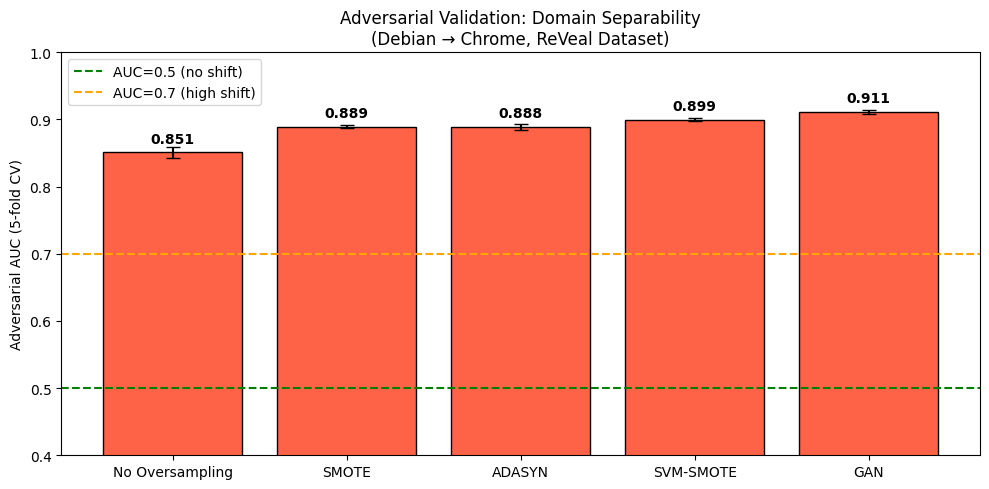

  Saved → adversarial_validation_barchart.png


In [11]:
print("=" * 45)
print("Bar Chart")
print("=" * 45)

conditions = ["No Oversampling", "SMOTE", "ADASYN", "SVM-SMOTE", "GAN"]
missing    = [c for c in conditions if c not in results]
if missing:
    print(f"  WARNING: Missing results for {missing}. Run those blocks first.")
else:
    aucs   = [results[c][0] for c in conditions]
    stds   = [results[c][1] for c in conditions]
    colors = ["steelblue" if a < 0.7 else "tomato" for a in aucs]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(conditions, aucs, yerr=stds, capsize=5,
                  color=colors, edgecolor="black")
    ax.axhline(y=0.5, color="green",  linestyle="--", linewidth=1.5, label="AUC=0.5 (no shift)")
    ax.axhline(y=0.7, color="orange", linestyle="--", linewidth=1.5, label="AUC=0.7 (high shift)")
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel("Adversarial AUC (5-fold CV)")
    ax.set_title("Adversarial Validation: Domain Separability\n(Debian → Chrome, ReVeal Dataset)")
    ax.legend()
    for bar, auc in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{auc:.3f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.savefig("adversarial_validation_barchart.png", dpi=300)
    plt.show()
    print("  Saved → adversarial_validation_barchart.png")

 ROC Curves


  Plotting ROC curves: 100%|█████████████████████████████| 5/5 [51:36<00:00, 619.29s/it]


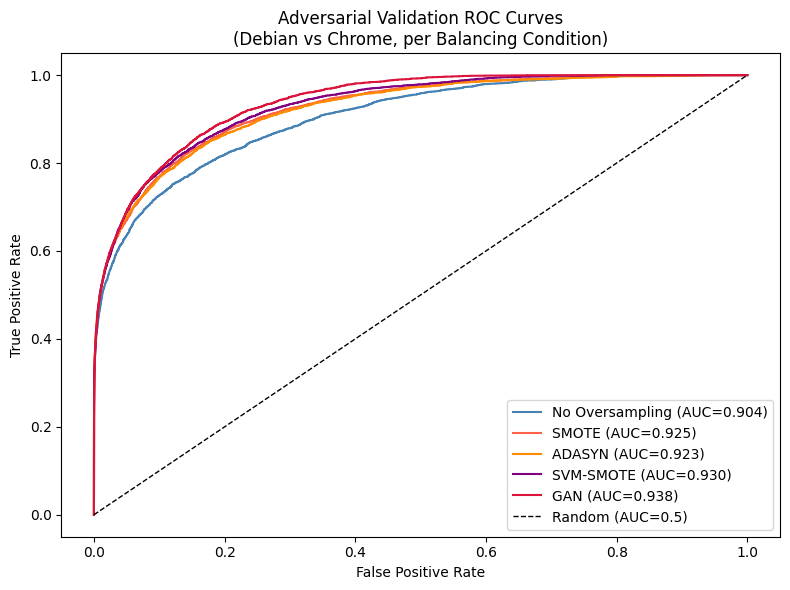

  Saved → adversarial_validation_roc.png


In [12]:
print("=" * 45)
print(" ROC Curves")
print("=" * 45)

# Ensure all embeddings are in memory
embedding_map = {
    "No Oversampling": debian_emb_scaled,
    "SMOTE":           np.load("../dataset/debian_smote.npy")      if "debian_smote"     not in dir() else debian_smote,
    "ADASYN":          np.load("../dataset/debian_adasyn.npy")     if "debian_adasyn"    not in dir() else debian_adasyn,
    "SVM-SMOTE":       np.load("../dataset/debian_svmsmote.npy")   if "debian_svmsmote"  not in dir() else debian_svmsmote,
    "GAN":             np.load("../dataset/debian_gan_embeddings.npy") if "debian_gan"   not in dir() else debian_gan,
}

color_map = {
    "No Oversampling": "steelblue",
    "SMOTE":           "tomato",
    "ADASYN":          "darkorange",
    "SVM-SMOTE":       "purple",
    "GAN":             "crimson",
}

def plot_roc(source_emb, target_emb, label, ax, color):
    X = np.vstack([source_emb, target_emb])
    y = np.array([0] * len(source_emb) + [1] * len(target_emb))
    clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    clf.fit(X, y)
    proba      = clf.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, proba)
    auc        = roc_auc_score(y, proba)
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})", color=color)

fig, ax = plt.subplots(figsize=(8, 6))
for label in tqdm(embedding_map, desc="  Plotting ROC curves"):
    plot_roc(embedding_map[label], chrome_emb_scaled, label, ax, color_map[label])

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Adversarial Validation ROC Curves\n(Debian vs Chrome, per Balancing Condition)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("adversarial_validation_roc.png", dpi=300)
plt.show()
print("  Saved → adversarial_validation_roc.png")